In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from PIL import Image
import requests
from io import BytesIO
from tqdm import tqdm

from transformers import (
    CLIPModel,
    CLIPProcessor,
    SiglipModel,
    SiglipProcessor,
    BitsAndBytesConfig
)

from peft import LoraConfig, get_peft_model, PeftModel

/home/mokar/.cache/pypoetry/virtualenvs/clip-asos-6tswlvn3-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cuda.matmul.allow_tf32 = True

# Dataset

In [3]:
def load_image(url, timeout=5):
    response = requests.get(url, timeout=timeout)
    return Image.open(BytesIO(response.content)).convert("RGB")

In [4]:
class ClipDataset(Dataset):
    def __init__(self, csv_path, processor):
        self.df = pd.read_csv(csv_path)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = load_image(row["im"])
        text = row["text"]

        inputs = self.processor(
            images=image,
            text=text,
            return_tensors="pt",
            padding="max_length",
            truncation=True
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0)
        }

# Dataloader

In [5]:
def collate_fn(batch):
    return {
        k: torch.stack([b[k] for b in batch])
        for k in batch[0]
    }


processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
    )

train_ds = ClipDataset("train.csv", processor)
val_ds   = ClipDataset("val.csv", processor)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


# Lora Config

In [6]:
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
)

model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32",
    quantization_config=bnb_config,
    device_map="auto"
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 983,040 || all params: 152,260,353 || trainable%: 0.6456


# Training

In [7]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

In [8]:
def clip_loss(image_embeds, text_embeds, temperature=0.07):
    logits = image_embeds @ text_embeds.T / temperature
    labels = torch.arange(len(logits), device=logits.device)

    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)

    return (loss_i + loss_t) / 2

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        # loss = outputs.loss

        img = F.normalize(outputs.image_embeds, dim=-1)
        txt = F.normalize(outputs.text_embeds, dim=-1)

        loss = clip_loss(img, txt)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    img_embs = []
    txt_embs = []

    for batch in tqdm(loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)

        img = F.normalize(outputs.image_embeds, dim=-1)
        txt = F.normalize(outputs.text_embeds, dim=-1)

        img_embs.append(img.cpu())
        txt_embs.append(txt.cpu())

    img_embs = torch.cat(img_embs)
    txt_embs = torch.cat(txt_embs)

    sim = img_embs @ txt_embs.T
    ranks = sim.argmax(dim=1)

    recall_at_1 = (ranks == torch.arange(len(ranks))).float().mean()
    return recall_at_1.item()

In [9]:
EPOCHS = 1

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    r1 = evaluate(model, val_loader)

    print(f"[Epoch {epoch+1}] loss={train_loss:.4f} | R@1={r1:.4f}")

  0%|          | 0/2998 [01:40<?, ?it/s]


KeyboardInterrupt: 

# Save weights

In [12]:
import os
from google.cloud import storage
def upload_folder_to_gcs(
    local_folder,
    bucket_name,
    gcs_prefix
):
    client = storage.Client()
    bucket = client.bucket(bucket_name)

    for root, _, files in os.walk(local_folder):
        for file in files:
            local_path = os.path.join(root, file)
            rel_path = os.path.relpath(local_path, local_folder)
            blob_path = os.path.join(gcs_prefix, rel_path)

            blob = bucket.blob(blob_path)
            blob.upload_from_filename(local_path)

            print(f"⬆️ {local_path} → gs://{bucket_name}/{blob_path}")

In [13]:
save_dir = "clip_lora_ckpt"
BUCKET = "clip-asos"

model.save_pretrained(save_dir)
processor.save_pretrained(save_dir)

upload_folder_to_gcs(
    local_folder=save_dir,
    bucket_name=BUCKET,
    gcs_prefix=f"models/{save_dir}"
)

⬆️ clip_lora_ckpt/vocab.json → gs://clip-asos/models/clip_lora_ckpt/vocab.json
⬆️ clip_lora_ckpt/special_tokens_map.json → gs://clip-asos/models/clip_lora_ckpt/special_tokens_map.json
⬆️ clip_lora_ckpt/README.md → gs://clip-asos/models/clip_lora_ckpt/README.md
⬆️ clip_lora_ckpt/merges.txt → gs://clip-asos/models/clip_lora_ckpt/merges.txt
⬆️ clip_lora_ckpt/adapter_config.json → gs://clip-asos/models/clip_lora_ckpt/adapter_config.json
⬆️ clip_lora_ckpt/preprocessor_config.json → gs://clip-asos/models/clip_lora_ckpt/preprocessor_config.json
⬆️ clip_lora_ckpt/adapter_model.safetensors → gs://clip-asos/models/clip_lora_ckpt/adapter_model.safetensors
⬆️ clip_lora_ckpt/tokenizer.json → gs://clip-asos/models/clip_lora_ckpt/tokenizer.json
⬆️ clip_lora_ckpt/tokenizer_config.json → gs://clip-asos/models/clip_lora_ckpt/tokenizer_config.json


# Load Weights

In [14]:
def download_folder_from_gcs(
    bucket_name,
    gcs_prefix,
    local_folder
):
    client = storage.Client()
    bucket = client.bucket(bucket_name)

    blobs = bucket.list_blobs(prefix=gcs_prefix)

    for blob in blobs:
        if blob.name.endswith("/"):
            continue

        rel_path = os.path.relpath(blob.name, gcs_prefix)
        local_path = os.path.join(local_folder, rel_path)

        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        blob.download_to_filename(local_path)

        print(f"⬇️ gs://{bucket_name}/{blob.name} → {local_path}")

In [15]:
from transformers import CLIPModel, CLIPProcessor
from peft import PeftModel
import torch

download_folder_from_gcs(
    bucket_name=BUCKET,
    gcs_prefix=f"models/{save_dir}",
    local_folder=save_dir
)

base_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32",
    torch_dtype=torch.float16,
    device_map="auto"
)

model = PeftModel.from_pretrained(
    base_model,
    save_dir,
)

processor = CLIPProcessor.from_pretrained(save_dir)

model.eval()

⬇️ gs://clip-asos/models/clip_lora_ckpt/README.md → clip_lora_ckpt/README.md
⬇️ gs://clip-asos/models/clip_lora_ckpt/adapter_config.json → clip_lora_ckpt/adapter_config.json
⬇️ gs://clip-asos/models/clip_lora_ckpt/adapter_model.safetensors → clip_lora_ckpt/adapter_model.safetensors
⬇️ gs://clip-asos/models/clip_lora_ckpt/merges.txt → clip_lora_ckpt/merges.txt
⬇️ gs://clip-asos/models/clip_lora_ckpt/preprocessor_config.json → clip_lora_ckpt/preprocessor_config.json
⬇️ gs://clip-asos/models/clip_lora_ckpt/special_tokens_map.json → clip_lora_ckpt/special_tokens_map.json
⬇️ gs://clip-asos/models/clip_lora_ckpt/tokenizer.json → clip_lora_ckpt/tokenizer.json
⬇️ gs://clip-asos/models/clip_lora_ckpt/tokenizer_config.json → clip_lora_ckpt/tokenizer_config.json


`torch_dtype` is deprecated! Use `dtype` instead!


⬇️ gs://clip-asos/models/clip_lora_ckpt/vocab.json → clip_lora_ckpt/vocab.json


PeftModel(
  (base_model): LoraModel(
    (model): CLIPModel(
      (text_model): CLIPTextTransformer(
        (embeddings): CLIPTextEmbeddings(
          (token_embedding): Embedding(49408, 512)
          (position_embedding): Embedding(77, 512)
        )
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-11): 12 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): lora.Linear(
                  (base_layer): Linear(in_features=512, out_features=512, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=512, out_features=8, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=8, out_features=512, bias=False)
                  )
                  (lora_embedding_A): ParameterDict()
   

# TSNE

In [19]:
from sklearn.manifold import TSNE
import numpy as np

def extract_image_embeddings(model, dataset, n=100):
    imgs = []
    embs = []

    for i in range(n):
        sample = dataset[i]
        pixel_values = sample["pixel_values"].unsqueeze(0).to(device)
        input_ids = sample["input_ids"].unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(pixel_values=pixel_values, input_ids=input_ids)
            emb = F.normalize(outputs.image_embeds, dim=-1)

        imgs.append(load_image(dataset.df.iloc[i]["im"]))
        embs.append(emb.cpu().numpy()[0])

    return imgs, np.vstack(embs)

In [20]:
imgs, embs = extract_image_embeddings(model, val_ds, n=100)

tsne = TSNE(
    n_components=2,
    perplexity=15,
    learning_rate="auto",
    init="random",
    random_state=42
)

coords = tsne.fit_transform(embs)

In [24]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
def plot_tsne_canvas(
    images,
    coords,
    width=4000,
    height=3000,
    max_dim=125,
):
    tx, ty = coords[:, 0], coords[:, 1]
    tx = (tx - tx.min()) / (tx.max() - tx.min())
    ty = (ty - ty.min()) / (ty.max() - ty.min())
    full_image = Image.new("RGBA", (width, height), (255, 255, 255, 255))

    for img, x, y in zip(images, tx, ty):
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)

        img = img.convert("RGBA")

        rs = max(1, img.width / max_dim, img.height / max_dim)
        img = img.resize(
            (int(img.width / rs), int(img.height / rs)),
            Image.LANCZOS
        )

        px = int((width - max_dim) * x)
        py = int((height - max_dim) * y)

        full_image.paste(img, (px, py), mask=img)

    return full_image

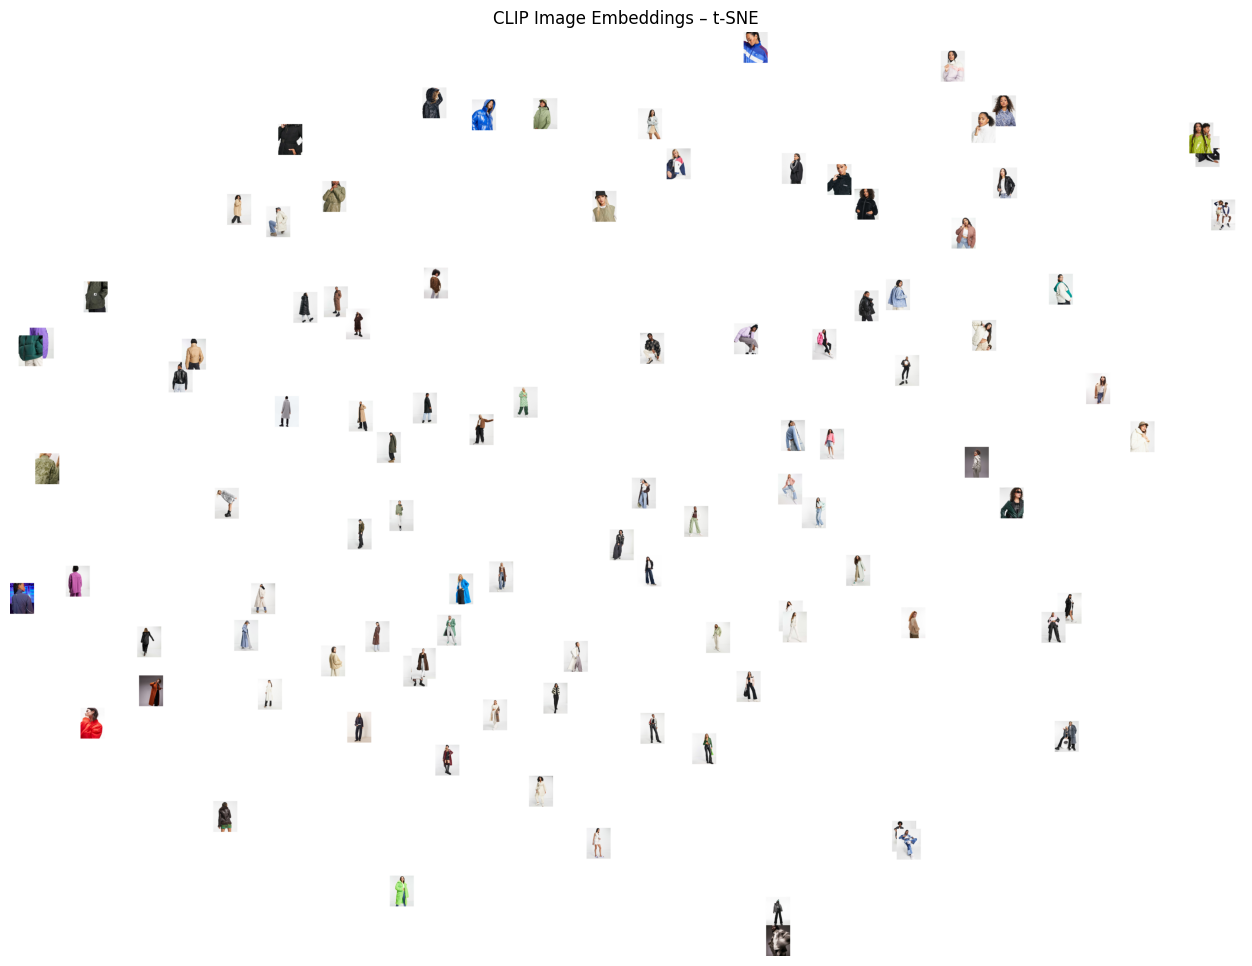

In [25]:
canvas = plot_tsne_canvas(
    images=imgs,
    coords=coords,
    width=4000,
    height=3000,
    max_dim=100
)

plt.figure(figsize=(16, 12))
plt.imshow(canvas)
plt.axis("off")
plt.title("CLIP Image Embeddings – t-SNE")
plt.show()